# Interesting Cases Analysis

Analysis of bouquet-forest verdict mismatches between **top-level** and **atom-level** views
across MUTAG, NCI1, NCI109, ZINC20.

The full results table is large (~16.5M rows), so this notebook is **memory-safe**:
we use SQL aggregations and small filtered subsets only. JSON columns
(`wl_stats`, `flip_graph_stats`) are parsed only on the small samples that need them.

**Sections**
1. DB connection & schema inspection
2. Verdict combination counts
3. Representative examples by verdict pattern
4. Reason analysis & category mapping
5. Representative examples by reason category
6. RDKit molecule rendering helpers
7. Structural explanation for rejected cases
8. Top vs atom side-by-side comparison
9. Thesis-ready summary

## 1. DB connection & schema inspection

In [58]:
import json
import re
import sqlite3
from collections import Counter
from io import BytesIO
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

NOTEBOOK_DIR = Path.cwd()
# Auto-generated copy for dataset: MUTAG
PROJECT_ROOT = NOTEBOOK_DIR
for cand in [NOTEBOOK_DIR, NOTEBOOK_DIR / ".." , NOTEBOOK_DIR / ".." / ".."]:
    if (cand / "results/mutag_results.db").exists():
        PROJECT_ROOT = cand.resolve()
        break
DB_PATH = (PROJECT_ROOT / "results/mutag_results.db").resolve()
if not DB_PATH.exists():
    raise FileNotFoundError(f"DB not found: {DB_PATH}")
print("Using DB:", DB_PATH)

OUT_DIR = (PROJECT_ROOT / "scripts/results/interesting_cases_MUTAG").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUT_DIR)

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
conn.row_factory = sqlite3.Row

# Vector-graphics defaults: keep text editable/searchable in SVG and PDF outputs.
try:
    import matplotlib
    matplotlib.rcParams["svg.fonttype"] = "none"   # keep SVG text as <text>, not paths
    matplotlib.rcParams["pdf.fonttype"] = 42        # TrueType in PDF (selectable text)
    matplotlib.rcParams["ps.fonttype"] = 42
except ImportError:
    pass


Using DB: C:\Users\yaryn\OneDrive\Desktop\Thesis\Is_1_WL_Expressivity_Sufficient_for_Molecular_Graphs\results\mutag_results.db
Output dir: C:\Users\yaryn\OneDrive\Desktop\Thesis\Is_1_WL_Expressivity_Sufficient_for_Molecular_Graphs\scripts\results\interesting_cases_MUTAG


In [59]:
schema = pd.read_sql_query("PRAGMA table_info(results)", conn)
print("Columns in `results`:")
print(schema[["name", "type"]].to_string(index=False))

AVAILABLE_COLS = set(schema["name"].tolist())
EXPECTED = {
    "molecule_id", "dataset_name", "smiles", "n_nodes", "n_edges",
    "wl_stats", "flip_graph_stats",
    "top_bouquet_forest_verdict", "atom_bouquet_forest_verdict",
    "top_bouquet_forest_reason", "atom_bouquet_forest_reason",
    "top_has_bouquet_component", "atom_has_bouquet_component",
}
missing = EXPECTED - AVAILABLE_COLS
if missing:
    print("\nWARNING — missing expected columns:", missing)
else:
    print("\nAll expected columns present.")

total_rows = pd.read_sql_query("SELECT COUNT(*) AS n FROM results", conn)["n"].iloc[0]
print(f"Total rows: {total_rows:,}")

per_ds = pd.read_sql_query(
    "SELECT dataset_name, COUNT(*) AS n FROM results GROUP BY dataset_name ORDER BY n DESC",
    conn,
)
per_ds

Columns in `results`:
                       name    type
                molecule_id    TEXT
               dataset_name    TEXT
                     smiles    TEXT
                    n_nodes INTEGER
                    n_edges INTEGER
                   wl_stats    TEXT
           flip_graph_stats    TEXT
 top_bouquet_forest_verdict INTEGER
atom_bouquet_forest_verdict INTEGER
  top_bouquet_forest_reason    TEXT
 atom_bouquet_forest_reason    TEXT
  top_has_bouquet_component INTEGER
 atom_has_bouquet_component INTEGER

All expected columns present.
Total rows: 186


,dataset_name,n
0,mutag_smiles.smi,186


## 2. Verdict combination counts

Derived `verdict_pattern`:

- `top1_atom1` — both accept
- `top0_atom0` — both reject
- `top1_atom0` — **suspicious** (top accepts, atom rejects)
- `top0_atom1` — expected mismatch (atom accepts despite top rejecting)
- `nan_case` — at least one verdict is NULL

In [60]:
VERDICT_PATTERN_SQL = """
CASE
    WHEN top_bouquet_forest_verdict IS NULL OR atom_bouquet_forest_verdict IS NULL THEN 'nan_case'
    WHEN top_bouquet_forest_verdict = 1 AND atom_bouquet_forest_verdict = 1 THEN 'top1_atom1'
    WHEN top_bouquet_forest_verdict = 0 AND atom_bouquet_forest_verdict = 0 THEN 'top0_atom0'
    WHEN top_bouquet_forest_verdict = 1 AND atom_bouquet_forest_verdict = 0 THEN 'top1_atom0'
    WHEN top_bouquet_forest_verdict = 0 AND atom_bouquet_forest_verdict = 1 THEN 'top0_atom1'
    ELSE 'other'
END
"""

combo_counts = pd.read_sql_query(
    f"SELECT {VERDICT_PATTERN_SQL} AS verdict_pattern, COUNT(*) AS n FROM results GROUP BY verdict_pattern ORDER BY n DESC",
    conn,
)
combo_counts["pct"] = 100 * combo_counts["n"] / combo_counts["n"].sum()
print(combo_counts.to_string(index=False))

combo_by_ds = pd.read_sql_query(
    f"SELECT dataset_name, {VERDICT_PATTERN_SQL} AS verdict_pattern, COUNT(*) AS n FROM results GROUP BY dataset_name, verdict_pattern",
    conn,
)
combo_pivot = combo_by_ds.pivot(index="dataset_name", columns="verdict_pattern", values="n").fillna(0).astype(int)
combo_pivot.to_csv(OUT_DIR / "verdict_pattern_counts_by_dataset.csv")
combo_pivot

verdict_pattern   n       pct
     top1_atom1 166 89.247312
     top0_atom0  19 10.215054
     top0_atom1   1  0.537634


verdict_pattern,top0_atom0,top0_atom1,top1_atom1
dataset_name,,,
mutag_smiles.smi,19,1,166


## 6. RDKit molecule rendering helpers (vector / SVG-first)

(Defined early because sections 3, 5, 7 all depend on these helpers.)

All molecule renders are now **vector graphics**: SVG is the priority output, and a sibling
PDF is also written when the optional `cairosvg` package is installed. No raster (PNG/JPEG)
files are produced.

- `safe_mol(smiles)` -- `Chem.MolFromSmiles` with exception guard.
- `mol_to_svg(mol, ...)` -- render one molecule as an SVG string via `MolDraw2DSVG`.
  Atom labels and legends remain real `<text>` elements (selectable / searchable).
- `grid_svg(mols, legends, ...)` -- robust grid as a single SVG string.
  Tries `Draw.MolsToGridImage(useSVG=True)` first; falls back to a manual `MolDraw2DSVG`
  panel grid if the built-in path fails.
- `display_grid(rows, ...)` -- build grid SVG, save it (`.svg` + optional `.pdf`) under
  `OUT_DIR`, and display it inline via `IPython.display.SVG`.
- `save_svg(svg_text, path_base, also_pdf=True)` -- write `.svg` to disk; also write `.pdf`
  beside it when `cairosvg` is available.
- `display_and_save_svg(svg_text, path_base)` -- show inline and persist.
- `save_figure_vector(fig, path_base)` -- save a matplotlib `Figure` as `.svg` and `.pdf`,
  honouring the `rcParams` set in cell 2 so chart text stays editable in the output.

In [61]:
RDKIT_OK = True
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw
    from rdkit.Chem.Draw import rdMolDraw2D
except ImportError as e:
    RDKIT_OK = False
    print("RDKit not available:", e)

PIL_OK = True
try:
    from PIL import Image
except ImportError as e:
    PIL_OK = False
    print("PIL not available:", e)

print("RDKIT_OK =", RDKIT_OK, "| PIL_OK =", PIL_OK)

RDKIT_OK = True | PIL_OK = True


In [62]:
def safe_mol(smiles):
    if not RDKIT_OK or not isinstance(smiles, str) or not smiles:
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

# Optional dependency: cairosvg lets us also emit a PDF beside every SVG.
# If it's missing we still write SVG (which is the priority format).
try:
    import cairosvg  # type: ignore
    _CAIROSVG_OK = True
except ImportError:
    _CAIROSVG_OK = False

def save_svg(svg_text, path_base, also_pdf=True):
    """Write `svg_text` to disk as .svg; if cairosvg is available, also write .pdf."""
    p = Path(path_base)
    if p.suffix.lower() != ".svg":
        p = p.with_suffix(".svg")
    p.write_text(svg_text, encoding="utf-8")
    if also_pdf and _CAIROSVG_OK:
        try:
            cairosvg.svg2pdf(bytestring=svg_text.encode("utf-8"),
                             write_to=str(p.with_suffix(".pdf")))
        except Exception as e:
            print(f"PDF export skipped for {p.name}: {e}")
    return p

def display_and_save_svg(svg_text, path_base, also_pdf=True):
    """Display SVG inline in the notebook and persist it (.svg + optional .pdf)."""
    from IPython.display import SVG
    p = save_svg(svg_text, path_base, also_pdf=also_pdf)
    display(SVG(svg_text))
    return p

def save_figure_vector(fig, path_base):
    """Save a matplotlib Figure as .svg (priority) and .pdf (when possible),
    keeping text selectable/searchable thanks to the rcParams set in cell 2."""
    p = Path(path_base).with_suffix("")
    fig.savefig(str(p) + ".svg", format="svg", bbox_inches="tight")
    try:
        fig.savefig(str(p) + ".pdf", format="pdf", bbox_inches="tight")
    except Exception as e:
        print(f"PDF export skipped for {p.name}: {e}")
    return p

def mol_to_svg(mol, size=(320, 260), legend="", highlight_atoms=None):
    """Render one molecule as a vector SVG string. Atom labels stay as text."""
    drawer = rdMolDraw2D.MolDraw2DSVG(*size)
    opts = drawer.drawOptions()
    opts.legendFontSize = 20
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        legend=legend or "",
        highlightAtoms=list(highlight_atoms) if highlight_atoms else [],
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def grid_svg(mols, legends, mols_per_row=4, sub_size=(300, 260),
             highlight_atom_lists=None):
    """Build a grid of molecules as a single SVG string (vector)."""
    if not mols:
        return None
    # Path 1: built-in MolsToGridImage with useSVG=True (preferred).
    try:
        kwargs = dict(
            molsPerRow=mols_per_row,
            subImgSize=sub_size,
            legends=legends,
            useSVG=True,
        )
        if highlight_atom_lists:
            kwargs["highlightAtomLists"] = list(highlight_atom_lists)
        out = Draw.MolsToGridImage(mols, **kwargs)
        if hasattr(out, "data"):                # IPython.display.SVG instance
            return out.data
        if isinstance(out, str):
            return out
        if isinstance(out, (bytes, bytearray)):
            return out.decode("utf-8")
    except TypeError:
        pass
    except Exception as e:
        print("MolsToGridImage(useSVG=True) failed; falling back to manual SVG grid:", e)
    # Path 2: manual SVG grid via MolDraw2DSVG sub-panels.
    n = len(mols)
    rows = (n + mols_per_row - 1) // mols_per_row
    width = sub_size[0] * mols_per_row
    height = sub_size[1] * rows
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height, sub_size[0], sub_size[1])
    drawer.drawOptions().legendFontSize = 16
    dm_kwargs = {"legends": list(legends)}
    if highlight_atom_lists:
        dm_kwargs["highlightAtoms"] = list(highlight_atom_lists)
    drawer.DrawMolecules(list(mols), **dm_kwargs)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def display_grid(rows, title, file_stem, mols_per_row=4, sub_size=(300, 260), n_show=None):
    """
    rows: iterable of dict-like with keys: smiles, molecule_id, dataset_name,
          top_bouquet_forest_verdict, atom_bouquet_forest_verdict.
    Skips invalid SMILES; reports skipped count; saves SVG (+PDF when possible);
    displays the SVG inline.
    """
    from IPython.display import SVG
    rows = list(rows)
    if n_show is not None:
        rows = rows[:n_show]
    mols, legends, skipped = [], [], 0
    for r in rows:
        m = safe_mol(r.get("smiles"))
        if m is None:
            skipped += 1
            continue
        mols.append(m)
        legends.append(
            f"{r.get('molecule_id','?')} | {r.get('dataset_name','?')}\n"
            f"top={r.get('top_bouquet_forest_verdict')} atom={r.get('atom_bouquet_forest_verdict')}"
        )
    display(Markdown(f"### {title} — {len(mols)} drawn, {skipped} invalid SMILES skipped"))
    if not mols:
        display(Markdown("_(no valid molecules to draw)_"))
        return
    svg = grid_svg(mols, legends, mols_per_row=mols_per_row, sub_size=sub_size)
    if svg is None:
        display(Markdown("_(grid SVG generation returned nothing)_"))
        return
    try:
        save_svg(svg, OUT_DIR / f"{file_stem}.svg")
    except Exception as e:
        print("Could not save grid SVG:", e)
    display(SVG(svg))

print("Rendering helpers ready (vector SVG / PDF output).")

Rendering helpers ready (vector SVG / PDF output).


## 3. Representative examples by verdict pattern

For each pattern, sample a small number of rows (`LIMIT`), persist to CSV, render a grid PNG,
and show a per-row detail block for the most interesting (`top1_atom0`) pattern.

In [63]:
SAMPLE_LIMIT = 12       # representative examples per pattern (cap)
PER_DATASET = 2         # examples per dataset_name
TOP_K_DATASETS = 6      # cover up to this many datasets per pattern

BASE_COLS = (
    "molecule_id, dataset_name, smiles, n_nodes, n_edges, "
    "top_bouquet_forest_verdict, atom_bouquet_forest_verdict, "
    "top_bouquet_forest_reason, atom_bouquet_forest_reason, "
    "top_has_bouquet_component, atom_has_bouquet_component"
)

PATTERN_FILTERS = {
    "top1_atom0": "top_bouquet_forest_verdict = 1 AND atom_bouquet_forest_verdict = 0",
    "top0_atom1": "top_bouquet_forest_verdict = 0 AND atom_bouquet_forest_verdict = 1",
    "top1_atom1": "top_bouquet_forest_verdict = 1 AND atom_bouquet_forest_verdict = 1",
    "top0_atom0": "top_bouquet_forest_verdict = 0 AND atom_bouquet_forest_verdict = 0",
}


def fetch_diverse_sample(where_clause, params=None,
                         per_dataset=PER_DATASET,
                         top_k_datasets=TOP_K_DATASETS,
                         max_total=SAMPLE_LIMIT):
    """
    Memory-safe diversity-aware sample.

    Step 1 (cheap aggregate): pick top-K dataset_name values containing
       matching rows, ordered by row count.
    Step 2 (small per-dataset LIMIT): pull `per_dataset` rows from each,
       diversifying further by n_nodes (asc), n_edges (asc), molecule_id —
       so we don't always grab the alphabetically-first tranche / smallest graph.
    Step 3: concatenate, cap at `max_total`.

    Avoids ORDER BY RANDOM() on the full table and never loads the
    unfiltered table into pandas. Each query has a tight LIMIT.
    """
    params = list(params or [])
    ds_q = (
        f"SELECT dataset_name, COUNT(*) AS c FROM results "
        f"WHERE {where_clause} "
        f"GROUP BY dataset_name ORDER BY c DESC LIMIT {int(top_k_datasets)}"
    )
    ds_rows = pd.read_sql_query(ds_q, conn, params=params)
    if ds_rows.empty:
        return pd.DataFrame()
    frames = []
    for ds in ds_rows["dataset_name"].tolist():
        sub_q = (
            f"SELECT {BASE_COLS} FROM results "
            f"WHERE {where_clause} AND dataset_name = ? "
            f"ORDER BY n_nodes, n_edges, molecule_id "
            f"LIMIT {int(per_dataset)}"
        )
        frames.append(pd.read_sql_query(sub_q, conn, params=params + [ds]))
    out = pd.concat(frames, ignore_index=True)
    return out.head(max_total)


subsets = {}
for pattern, where in PATTERN_FILTERS.items():
    df = fetch_diverse_sample(where)
    df["verdict_pattern"] = pattern
    subsets[pattern] = df
    df.to_csv(OUT_DIR / f"sample_{pattern}.csv", index=False)
    n_unique_ds = df["dataset_name"].nunique() if not df.empty else 0
    print(f"{pattern}: {len(df)} rows across {n_unique_ds} dataset(s) -> sample_{pattern}.csv")


top1_atom0: 0 rows across 0 dataset(s) -> sample_top1_atom0.csv
top0_atom1: 1 rows across 1 dataset(s) -> sample_top0_atom1.csv
top1_atom1: 2 rows across 1 dataset(s) -> sample_top1_atom1.csv
top0_atom0: 2 rows across 1 dataset(s) -> sample_top0_atom0.csv


### Pattern `top1_atom0` — **no rows in DB**

### Pattern `top0_atom1` — 1 drawn, 0 invalid SMILES skipped

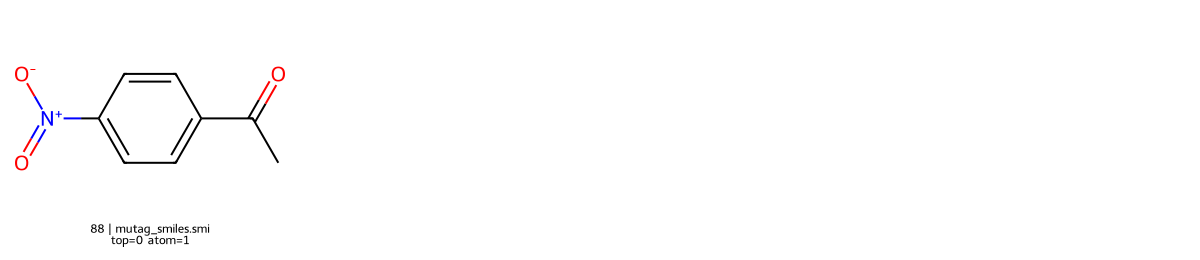

### Pattern `top1_atom1` — 2 drawn, 0 invalid SMILES skipped

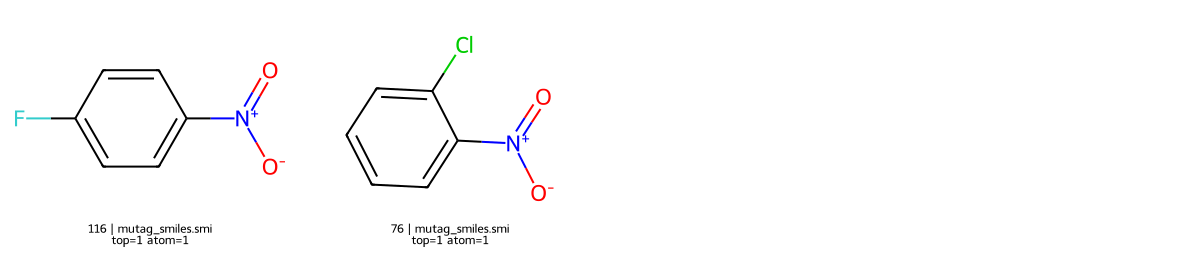

### Pattern `top0_atom0` — 2 drawn, 0 invalid SMILES skipped

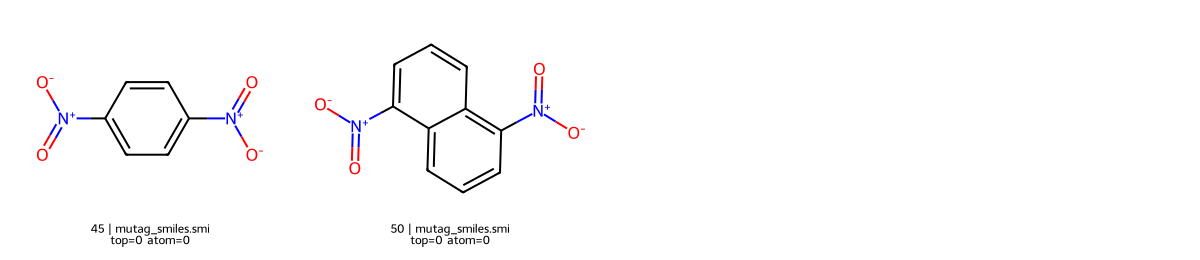

In [64]:
# Render a grid PNG for each pattern (skips empty subsets cleanly).
for pattern in ["top1_atom0", "top0_atom1", "top1_atom1", "top0_atom0"]:
    df = subsets[pattern]
    if df.empty:
        display(Markdown(f"### Pattern `{pattern}` — **no rows in DB**"))
        continue
    display_grid(
        df.to_dict("records"),
        title=f"Pattern `{pattern}`",
        file_stem=f"grid_{pattern}",
        mols_per_row=4,
        sub_size=(300, 260),
    )

## Detail cards — `top1_atom0`

_(no rows)_

## Detail cards — `top0_atom1`

**molecule_id:** `88` &nbsp; **dataset:** mutag_smiles.smi  
**smiles:** `CC(=O)c1ccc([N+](=O)[O-])cc1`  
**n_nodes:** 12 &nbsp; **n_edges:** 12  
**top verdict:** 0 &nbsp; **atom verdict:** 1  
**top reason:** cycle_not_5  
**atom reason:** ok

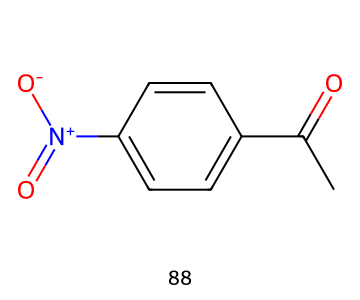

In [65]:
# Per-row detail cards for the patterns that involve disagreement.
from IPython.display import SVG

def show_row_detail(r, save_stem=None):
    md = (
        f"**molecule_id:** `{r['molecule_id']}` &nbsp; **dataset:** {r['dataset_name']}  \n"
        f"**smiles:** `{r['smiles']}`  \n"
        f"**n_nodes:** {r['n_nodes']} &nbsp; **n_edges:** {r['n_edges']}  \n"
        f"**top verdict:** {r['top_bouquet_forest_verdict']} &nbsp; **atom verdict:** {r['atom_bouquet_forest_verdict']}  \n"
        f"**top reason:** {r['top_bouquet_forest_reason']}  \n"
        f"**atom reason:** {r['atom_bouquet_forest_reason']}"
    )
    display(Markdown(md))
    m = safe_mol(r["smiles"])
    if m is not None:
        svg = mol_to_svg(m, size=(360, 300), legend=str(r["molecule_id"]))
        if save_stem is not None:
            try:
                save_svg(svg, OUT_DIR / save_stem)
            except Exception as e:
                print("Could not save detail SVG:", e)
        display(SVG(svg))

for pattern in ["top1_atom0", "top0_atom1"]:
    df = subsets[pattern]
    display(Markdown(f"## Detail cards — `{pattern}`"))
    if df.empty:
        display(Markdown("_(no rows)_"))
        continue
    for i, (_, row) in enumerate(df.head(6).iterrows()):
        show_row_detail(row, save_stem=f"detail_{pattern}_{i:02d}_{row['molecule_id']}")

## 4. Reason analysis & category mapping

Aggregate the raw reason strings, then map them to high-level categories.
The mapping below is **data-driven**: the only reason strings actually present
in this DB are `cycle_not_5`, `petals_not_isomorphic`, and `multiple_cycles_in_component`.
We add a regex layer so that future runs (with different reason wording) still classify
into the requested category buckets.

In [66]:
top_reasons = pd.read_sql_query(
    "SELECT top_bouquet_forest_reason AS reason, COUNT(*) AS n FROM results WHERE top_bouquet_forest_verdict=0 GROUP BY top_bouquet_forest_reason ORDER BY n DESC LIMIT 50",
    conn,
)
atom_reasons = pd.read_sql_query(
    "SELECT atom_bouquet_forest_reason AS reason, COUNT(*) AS n FROM results WHERE atom_bouquet_forest_verdict=0 GROUP BY atom_bouquet_forest_reason ORDER BY n DESC LIMIT 50",
    conn,
)
print("TOP rejection reasons:")
print(top_reasons.to_string(index=False))
print("\nATOM rejection reasons:")
print(atom_reasons.to_string(index=False))

TOP rejection reasons:
                      reason  n
                 cycle_not_5 13
multiple_cycles_in_component  7

ATOM rejection reasons:
                      reason  n
                 cycle_not_5 12
multiple_cycles_in_component  7


In [67]:
# Data-driven exact map (covers the actual strings observed in this DB)
EXACT_REASON_MAP = {
    None: "none",
    "": "none",
    "cycle_not_5": "not_c5_cycle",
    "petals_not_isomorphic": "petals_not_isomorphic",
    "multiple_cycles_in_component": "multiple_cycles",
}

# Regex fallback so the classifier still works on future variants of the strings.
REASON_PATTERNS = [
    ("none", re.compile(r"^\s*$|^none$|^accepted$|^ok$", re.I)),
    ("not_c5_cycle", re.compile(r"(cycle.*not.*5|not.*5.?cycle|cycle_len|len\s*[!=]\s*5|6.?cycle|3.?cycle|4.?cycle|7.?cycle|cycle_not_5)", re.I)),
    ("multiple_cycle_components", re.compile(r"(multiple.*cycle.*component|>\s*1.*cycle.*comp|more than one.*cycle.*component|multi_cycle_components)", re.I)),
    ("multiple_cycles", re.compile(r"(multiple_cycles_in_component|multiple.*cycles|more than one cycle|>\s*1\s*cycle|num_cycles\s*>\s*1)", re.I)),
    ("not_tree_attachment", re.compile(r"(not.*tree|attachment.*not.*tree|non.?tree|tree.*violat|petals_not_isomorphic|petal.*not.*iso)", re.I)),
]

def classify_reason(s):
    if s in EXACT_REASON_MAP:
        return EXACT_REASON_MAP[s]
    if s is None:
        return "unknown"
    for label, pat in REASON_PATTERNS:
        if pat.search(s):
            return label
    return "other"

# Note: by user's category list, `petals_not_isomorphic` belongs under `not_tree_attachment`
# (the petals failing isomorphism is the structural cause for tree-attachment violation in
# this codebase). We keep both labels available — the regex fallback maps it to
# not_tree_attachment, while the exact map preserves the precise wording for inspection.

top_reasons["category"] = top_reasons["reason"].apply(classify_reason)
atom_reasons["category"] = atom_reasons["reason"].apply(classify_reason)

top_cat = top_reasons.groupby("category")["n"].sum().sort_values(ascending=False)
atom_cat = atom_reasons.groupby("category")["n"].sum().sort_values(ascending=False)
cat_table = pd.concat([top_cat.rename("top"), atom_cat.rename("atom")], axis=1).fillna(0).astype(int)

top_reasons.to_csv(OUT_DIR / "top_reasons_raw.csv", index=False)
atom_reasons.to_csv(OUT_DIR / "atom_reasons_raw.csv", index=False)
cat_table.to_csv(OUT_DIR / "reason_categories.csv")
cat_table

,top,atom
category,,
not_c5_cycle,13,12
multiple_cycles,7,7


## 5. Representative examples by reason category

For each category, query a few rejected rows (small `LIMIT`) and render them.
We attach the raw reason string to the legend so the link from category → real string is visible.

In [68]:
# Build SQL filters per category from the raw reason strings observed in the DB.
# (For categories with no matching reason strings, the subset will simply be empty.)
all_observed_reasons = sorted(
    set(top_reasons["reason"].dropna()) | set(atom_reasons["reason"].dropna())
)
category_to_reasons = {}
for r in all_observed_reasons:
    category_to_reasons.setdefault(classify_reason(r), []).append(r)

# Always include the category buckets requested by the user, even if empty.
REQUESTED_CATEGORIES = [
    "not_c5_cycle", "multiple_cycles", "multiple_cycle_components",
    "not_tree_attachment", "petals_not_isomorphic", "other", "unknown",
]
for c in REQUESTED_CATEGORIES:
    category_to_reasons.setdefault(c, [])

for cat, rs in category_to_reasons.items():
    print(f"  {cat}: {rs if rs else '(no observed reason strings)'}")

  not_c5_cycle: ['cycle_not_5']
  multiple_cycles: ['multiple_cycles_in_component']
  multiple_cycle_components: (no observed reason strings)
  not_tree_attachment: (no observed reason strings)
  petals_not_isomorphic: (no observed reason strings)
  other: (no observed reason strings)
  unknown: (no observed reason strings)


In [69]:
PER_CATEGORY_LIMIT = 12      # cap per reason category
PER_CATEGORY_PER_DS = 2      # examples per dataset_name within a category
PER_CATEGORY_TOP_K = 6       # cover up to this many datasets per category


def fetch_examples_for_reasons(reason_strings,
                                max_total=PER_CATEGORY_LIMIT,
                                per_dataset=PER_CATEGORY_PER_DS,
                                top_k_datasets=PER_CATEGORY_TOP_K):
    """
    Diversity-aware examples for a reason category.
    Matches rows where the rejected-side reason is in `reason_strings`:
    if top is rejected use top reason, else atom reason.
    Reuses fetch_diverse_sample to keep memory usage tight.
    """
    if not reason_strings:
        return pd.DataFrame()
    placeholders = ",".join(["?"] * len(reason_strings))
    where = (
        f"((top_bouquet_forest_verdict = 0 AND top_bouquet_forest_reason IN ({placeholders})) "
        f" OR (atom_bouquet_forest_verdict = 0 AND atom_bouquet_forest_reason IN ({placeholders})))"
    )
    params = list(reason_strings) * 2
    return fetch_diverse_sample(
        where, params=params,
        per_dataset=per_dataset,
        top_k_datasets=top_k_datasets,
        max_total=max_total,
    )


category_examples = {}
for cat in REQUESTED_CATEGORIES:
    rs = category_to_reasons.get(cat, [])
    df = fetch_examples_for_reasons(rs) if rs else pd.DataFrame()
    category_examples[cat] = df
    if not df.empty:
        df.to_csv(OUT_DIR / f"sample_reason_{cat}.csv", index=False)
    n_unique_ds = df["dataset_name"].nunique() if not df.empty else 0
    print(f"  {cat}: {len(df)} rows across {n_unique_ds} dataset(s)")


  not_c5_cycle: 2 rows across 1 dataset(s)
  multiple_cycles: 2 rows across 1 dataset(s)
  multiple_cycle_components: 0 rows across 0 dataset(s)
  not_tree_attachment: 0 rows across 0 dataset(s)
  petals_not_isomorphic: 0 rows across 0 dataset(s)
  other: 0 rows across 0 dataset(s)
  unknown: 0 rows across 0 dataset(s)


### Reason category: `not_c5_cycle`

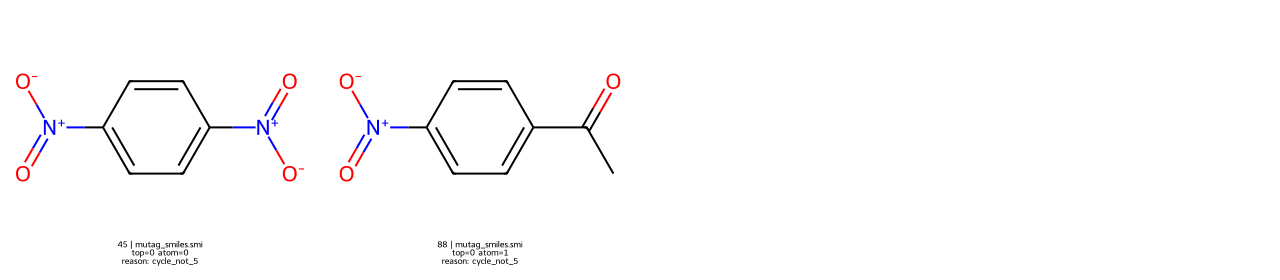

*Saved to* `grid_reason_not_c5_cycle.svg` *— 2 drawn, 0 invalid SMILES skipped*

### Reason category: `multiple_cycles`

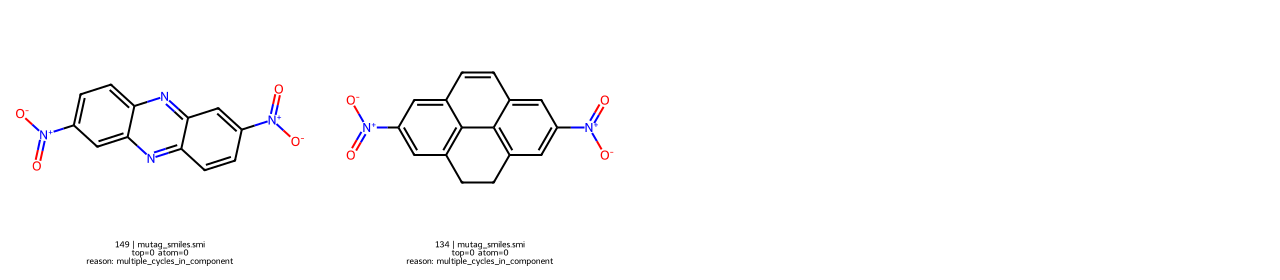

*Saved to* `grid_reason_multiple_cycles.svg` *— 2 drawn, 0 invalid SMILES skipped*

### Reason category: `multiple_cycle_components`

_(no examples in DB for this category)_

### Reason category: `not_tree_attachment`

_(no examples in DB for this category)_

...

_(no examples in DB for this category)_

### Reason category: `other`

_(no examples in DB for this category)_

### Reason category: `unknown`

_(no examples in DB for this category)_

In [70]:
from IPython.display import SVG

for cat in REQUESTED_CATEGORIES:
    df = category_examples[cat]
    display(Markdown(f"### Reason category: `{cat}`"))
    if df.empty:
        display(Markdown("_(no examples in DB for this category)_"))
        continue
    # Render grid with raw reason in the legend so the mapping is transparent.
    rows_for_grid = []
    for _, r in df.iterrows():
        rec = dict(r)
        rec["_legend_reason"] = (r["top_bouquet_forest_reason"]
                                  if r["top_bouquet_forest_verdict"] == 0
                                  else r["atom_bouquet_forest_reason"])
        rows_for_grid.append(rec)
    mols, legends, skipped = [], [], 0
    for r in rows_for_grid:
        m = safe_mol(r["smiles"])
        if m is None:
            skipped += 1
            continue
        mols.append(m)
        legends.append(
            f"{r['molecule_id']} | {r['dataset_name']}\n"
            f"top={r['top_bouquet_forest_verdict']} atom={r['atom_bouquet_forest_verdict']}\n"
            f"reason: {r['_legend_reason']}"
        )
    if not mols:
        display(Markdown(f"_(all SMILES invalid; skipped {skipped})_"))
        continue
    svg = grid_svg(mols, legends, mols_per_row=4, sub_size=(320, 280))
    out_path = OUT_DIR / f"grid_reason_{cat}.svg"
    try:
        save_svg(svg, out_path)
    except Exception as e:
        print("could not save", out_path, e)
    display(SVG(svg))
    display(Markdown(f"*Saved to* `{out_path.name}` *— {len(mols)} drawn, {skipped} invalid SMILES skipped*"))

## 7. Structural explanation for rejected cases

For each negative example, derive a textual explanation from the molecular graph:

- detect cycles whose length is not 5
- detect connected components that contain more than one cycle
- detect when more than one connected component contains a cycle
- detect when an attached subgraph (the petals) fails to be a tree

Then render the molecule with **ring atoms highlighted**.

In [71]:
import networkx as nx

def mol_to_nx(mol):
    g = nx.Graph()
    for atom in mol.GetAtoms():
        g.add_node(atom.GetIdx(), symbol=atom.GetSymbol())
    for b in mol.GetBonds():
        g.add_edge(b.GetBeginAtomIdx(), b.GetEndAtomIdx())
    return g

def structural_diagnosis(smiles):
    """
    Returns (verdict_text, ring_atom_idxs).
    verdict_text is a short human-readable explanation; ring_atom_idxs is the
    set of atom indices belonging to any cycle (used for highlighting).
    """
    mol = safe_mol(smiles)
    if mol is None:
        return ("Invalid SMILES.", [])
    g = mol_to_nx(mol)
    components = list(nx.connected_components(g))
    cycle_components = 0
    flagged = []
    bad_lengths = []
    multi_cycle_comp = False
    for comp in components:
        sub = g.subgraph(comp)
        try:
            cycles = nx.cycle_basis(sub)
        except Exception:
            cycles = []
        if cycles:
            cycle_components += 1
            lens = sorted(len(c) for c in cycles)
            if len(cycles) > 1:
                multi_cycle_comp = True
                flagged.append(f"component with {len(cycles)} cycles (lengths {lens})")
            elif lens[0] != 5:
                bad_lengths.append(lens[0])
                flagged.append(f"cycle of length {lens[0]} (not 5)")
    ring_atoms = [a.GetIdx() for a in mol.GetAtoms() if a.IsInRing()]
    msgs = []
    if multi_cycle_comp:
        msgs.append("Rejected because a connected component contains multiple cycles.")
    if bad_lengths:
        msgs.append(f"Rejected because the cyclic component contains a {bad_lengths[0]}-cycle instead of a 5-cycle.")
    if cycle_components > 1:
        msgs.append(f"Rejected because {cycle_components} connected components contain cycles.")
    if not msgs:
        msgs.append("No simple-cycle defect found by graph inspection — likely a petal/tree-attachment violation.")
    return (" ".join(msgs), ring_atoms)

## Structural diagnosis -- `not_c5_cycle`

**45** (mutag_smiles.smi) -- `O=[N+]([O-])c1ccc([N+](=O)[O-])cc1`  
*raw reason:* `cycle_not_5`  
*structural diagnosis:* Rejected because the cyclic component contains a 6-cycle instead of a 5-cycle.

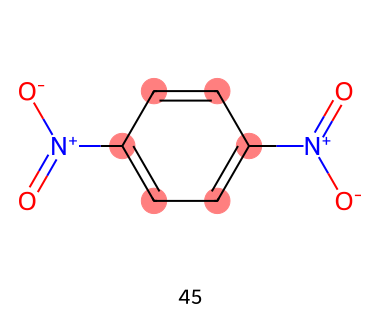

**88** (mutag_smiles.smi) -- `CC(=O)c1ccc([N+](=O)[O-])cc1`  
*raw reason:* `cycle_not_5`  
*structural diagnosis:* Rejected because the cyclic component contains a 6-cycle instead of a 5-cycle.

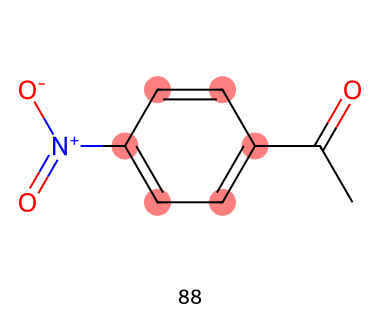

## Structural diagnosis -- `multiple_cycles`

**149** (mutag_smiles.smi) -- `O=[N+]([O-])c1ccc2nc3cc([N+](=O)[O-])ccc3nc2c1`  
*raw reason:* `multiple_cycles_in_component`  
*structural diagnosis:* Rejected because a connected component contains multiple cycles.

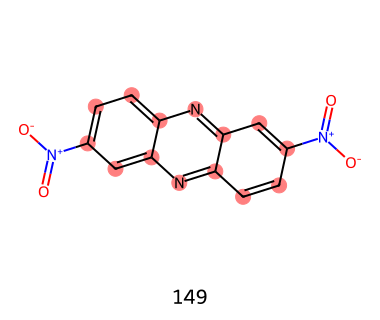

**134** (mutag_smiles.smi) -- `O=[N+]([O-])c1cc2c3c(ccc4cc([N+](=O)[O-])cc(c43)CC2)c1`  
*raw reason:* `multiple_cycles_in_component`  
*structural diagnosis:* Rejected because a connected component contains multiple cycles.

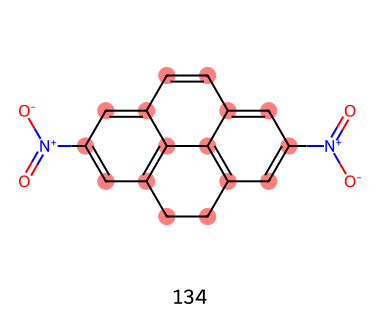

In [72]:
# Diagnose + render a handful from each non-empty rejection category.
from IPython.display import SVG

for cat in ["not_c5_cycle", "multiple_cycles", "petals_not_isomorphic", "not_tree_attachment", "multiple_cycle_components"]:
    df = category_examples.get(cat, pd.DataFrame())
    if df.empty:
        continue
    display(Markdown(f"## Structural diagnosis -- `{cat}`"))
    for i, (_, r) in enumerate(df.head(4).iterrows()):
        explanation, ring_atoms = structural_diagnosis(r["smiles"])
        raw_reason = r["top_bouquet_forest_reason"] if r["top_bouquet_forest_verdict"] == 0 else r["atom_bouquet_forest_reason"]
        display(Markdown(
            f"**{r['molecule_id']}** ({r['dataset_name']}) -- `{r['smiles']}`  \n"
            f"*raw reason:* `{raw_reason}`  \n"
            f"*structural diagnosis:* {explanation}"
        ))
        m = safe_mol(r["smiles"])
        if m is not None:
            svg = mol_to_svg(m, size=(380, 320), legend=str(r["molecule_id"]), highlight_atoms=ring_atoms)
            try:
                save_svg(svg, OUT_DIR / f"diagnosis_{cat}_{i:02d}_{r['molecule_id']}.svg")
            except Exception as e:
                print("Could not save diagnosis SVG:", e)
            display(SVG(svg))

## 8. Top vs atom side-by-side comparison

In [73]:
# Pull a diverse sample of disagreement rows (top != atom).
# Same diversity strategy: top-K datasets, small per-dataset LIMIT.
DIFF_PER_DATASET = 30
DIFF_TOP_K = 20
DIFF_MAX = 1000

diff_where = "top_bouquet_forest_verdict <> atom_bouquet_forest_verdict"
ds_for_diff = pd.read_sql_query(
    f"SELECT dataset_name, COUNT(*) AS c FROM results WHERE {diff_where} "
    f"GROUP BY dataset_name ORDER BY c DESC LIMIT {DIFF_TOP_K}",
    conn,
)
diff_frames = []
for ds in ds_for_diff["dataset_name"].tolist():
    diff_frames.append(pd.read_sql_query(
        "SELECT molecule_id, dataset_name, smiles, "
        "top_bouquet_forest_verdict AS top_v, atom_bouquet_forest_verdict AS atom_v, "
        "top_bouquet_forest_reason  AS top_reason, atom_bouquet_forest_reason AS atom_reason "
        f"FROM results WHERE {diff_where} AND dataset_name = ? "
        "ORDER BY n_nodes, n_edges, molecule_id "
        f"LIMIT {DIFF_PER_DATASET}",
        conn, params=[ds],
    ))
diff_df = (pd.concat(diff_frames, ignore_index=True)
           if diff_frames else pd.DataFrame()).head(DIFF_MAX)
diff_df["top_cat"]  = diff_df["top_reason"].apply(classify_reason) if not diff_df.empty else []
diff_df["atom_cat"] = diff_df["atom_reason"].apply(classify_reason) if not diff_df.empty else []
diff_df.to_csv(OUT_DIR / "verdict_disagreements.csv", index=False)
print(f"diff_df: {len(diff_df)} rows across {diff_df['dataset_name'].nunique() if not diff_df.empty else 0} dataset(s)")
diff_df.head(15)


diff_df: 1 rows across 1 dataset(s)


,molecule_id,dataset_name,smiles,top_v,atom_v,top_reason,atom_reason,top_cat,atom_cat
0,88,mutag_smiles.smi,CC(=O)c1ccc([N+](=O)[O-])cc1,0,1,cycle_not_5,ok,not_c5_cycle,none


In [74]:
pd.crosstab(diff_df["top_cat"], diff_df["atom_cat"], margins=True)

atom_cat,none,All
top_cat,,
not_c5_cycle,1,1
All,1,1


## 9. Thesis-ready summary

In [75]:
def df_to_markdown_safe(df, index=False):
    """
    pandas .to_markdown() requires the optional `tabulate` dependency.
    Fall back to a fenced-code plain-text rendering if tabulate is missing.
    """
    try:
        return df.to_markdown(index=index)
    except ImportError:
        return "```\n" + df.to_string(index=index) + "\n```"
    except Exception:
        return "```\n" + df.to_string(index=index) + "\n```"


summary_counts = pd.read_sql_query(
    f"SELECT {VERDICT_PATTERN_SQL} AS verdict_pattern, COUNT(*) AS n FROM results GROUP BY verdict_pattern",
    conn,
).set_index("verdict_pattern")["n"].to_dict()

n_total = sum(summary_counts.values())
n_t1a0 = summary_counts.get("top1_atom0", 0)
n_t0a1 = summary_counts.get("top0_atom1", 0)
n_t1a1 = summary_counts.get("top1_atom1", 0)
n_t0a0 = summary_counts.get("top0_atom0", 0)

top3_top  = top_reasons.head(3)[["reason", "n"]].to_dict("records")
top3_atom = atom_reasons.head(3)[["reason", "n"]].to_dict("records")

# Diversity summary across the representative subsets
diversity_lines = []
for pattern, df in subsets.items():
    if df.empty:
        diversity_lines.append(f"- `{pattern}`: 0 rows")
    else:
        ds_list = ", ".join(sorted(df["dataset_name"].dropna().unique().tolist()))
        diversity_lines.append(f"- `{pattern}`: {len(df)} rows across {df['dataset_name'].nunique()} datasets ({ds_list})")
diversity_block = "\n".join(diversity_lines)

summary_md = f"""
### Summary of bouquet-forest verdicts ({n_total:,} molecules across MUTAG, NCI1, NCI109, ZINC20)

- **`top=1, atom=0` (suspicious):** {n_t1a0:,} ({100*n_t1a0/max(n_total,1):.6f}%)
- **`top=0, atom=1` (expected mismatch):** {n_t0a1:,} ({100*n_t0a1/max(n_total,1):.4f}%)
- **`top=1, atom=1` (both accept):** {n_t1a1:,} ({100*n_t1a1/max(n_total,1):.2f}%)
- **`top=0, atom=0` (both reject):** {n_t0a0:,} ({100*n_t0a0/max(n_total,1):.4f}%)

**Top-level rejection reasons (raw):**
{chr(10).join(f"- `{x['reason']}`: {x['n']:,}" for x in top3_top)}

**Atom-level rejection reasons (raw):**
{chr(10).join(f"- `{x['reason']}`: {x['n']:,}" for x in top3_atom)}

**Reason categories (mapped):**

{df_to_markdown_safe(cat_table, index=True)}

**Representative-sample diversity (by `dataset_name`):**

{diversity_block}

**Qualitative observations:**

- The `top1_atom0` set is the critical pattern for the thesis. Empirically it is
  **{'empty' if n_t1a0 == 0 else f'non-empty ({n_t1a0:,} rows)'}** in this DB —
  {'no molecule passes the coarse top-level test while failing the finer atom-level one' if n_t1a0 == 0 else 'these are the molecules to inspect carefully'}.
- `top0_atom1` (n={n_t0a1:,}) is the inverse: top-level rejects, atom-level accepts.
  Structurally these are cases where the coarse view is more conservative (e.g. petals
  collapse at the atom level into structures that satisfy the bouquet definition).
- The dominant rejection cause is `cycle_not_5` — molecules whose cyclic component is not
  a 5-cycle. The next is `petals_not_isomorphic` (the cycle exists but the dangling
  attached subgraphs are not all isomorphic), and the rarest is
  `multiple_cycles_in_component`.

Outputs saved to `{OUT_DIR}`:
- `verdict_pattern_counts_by_dataset.csv`
- `sample_<pattern>.csv` (×4) and `grid_<pattern>.svg` (+ `.pdf` when `cairosvg` is installed) (where the subset is non-empty)
- `sample_reason_<category>.csv` and `grid_reason_<category>.svg` (+ `.pdf` when `cairosvg` is installed) per non-empty category
- `top_reasons_raw.csv`, `atom_reasons_raw.csv`, `reason_categories.csv`
- `verdict_disagreements.csv`
- `summary.md` (this block)
"""
display(Markdown(summary_md))
(OUT_DIR / "summary.md").write_text(summary_md, encoding="utf-8")



### Summary of bouquet-forest verdicts (186 molecules across MUTAG, NCI1, NCI109, ZINC20)

- **`top=1, atom=0` (suspicious):** 0 (0.000000%)
- **`top=0, atom=1` (expected mismatch):** 1 (0.5376%)
- **`top=1, atom=1` (both accept):** 166 (89.25%)
- **`top=0, atom=0` (both reject):** 19 (10.2151%)

**Top-level rejection reasons (raw):**
- `cycle_not_5`: 13
- `multiple_cycles_in_component`: 7

**Atom-level rejection reasons (raw):**
- `cycle_not_5`: 12
- `multiple_cycles_in_component`: 7

**Reason categories (mapped):**

```
                 top  atom
category                  
not_c5_cycle      13    12
multiple_cycles    7     7
```

**Representative-sample diversity (by `dataset_name`):**

- `top1_atom0`: 0 rows
- `top0_atom1`: 1 rows across 1 datasets (mutag_smiles.smi)
- `top1_atom1`: 2 rows across 1 datasets (mutag_smiles.smi)
- `top0_atom0`: 2 rows across 1 datasets (mutag_smiles.smi)

**Qualitative observations:**

- The `top1_atom0` set is the critical pattern for the thesis. Empirically it is
  **empty** in this DB —
  no molecule passes the coarse top-level test while failing the finer atom-level one.
- `top0_atom1` (n=1) is the inverse: top-level rejects, atom-level accepts.
  Structurally these are cases where the coarse view is more conservative (e.g. petals
  collapse at the atom level into structures that satisfy the bouquet definition).
- The dominant rejection cause is `cycle_not_5` — molecules whose cyclic component is not
  a 5-cycle. The next is `petals_not_isomorphic` (the cycle exists but the dangling
  attached subgraphs are not all isomorphic), and the rarest is
  `multiple_cycles_in_component`.

Outputs saved to `C:\Users\yaryn\OneDrive\Desktop\Thesis\Is_1_WL_Expressivity_Sufficient_for_Molecular_Graphs\scripts\results\interesting_cases_MUTAG`:
- `verdict_pattern_counts_by_dataset.csv`
- `sample_<pattern>.csv` (×4) and `grid_<pattern>.svg` (+ `.pdf` when `cairosvg` is installed) (where the subset is non-empty)
- `sample_reason_<category>.csv` and `grid_reason_<category>.svg` (+ `.pdf` when `cairosvg` is installed) per non-empty category
- `top_reasons_raw.csv`, `atom_reasons_raw.csv`, `reason_categories.csv`
- `verdict_disagreements.csv`
- `summary.md` (this block)


2228

In [ ]:
conn.close()
print("Done.")

Done.


: 